# Artifacts quick inspection

Esplorazione **a posteriori** degli artefatti già prodotti dalle pipeline in `data/derived/` — ogni sezione legge solo output già su disco (matrici, CSV di summary), non ricalcola mai la pipeline che li ha generati. Per ogni artefatto: caricamento, controlli di qualità (coerenza, range, valori mancanti/anomali) ed EDA (statistiche descrittive, distribuzioni).

## Lesion Matrices

### `lesion_matrix/21-07_s1.1`

#### Loading

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

deriv_dir = "/Users/emmatosato/Local Projects/PhD/NEMESIS_fs/data/derived/lesion_matrix/21-07_s1.1"

In [23]:
# Load Manifest
manifest_path = os.path.join(deriv_dir, "manifest.json")
with open(manifest_path, "r") as f:
    manifest = json.load(f)

print("Manifest:")
print(json.dumps(manifest, indent=2))

Manifest:
{
  "created_at": "2026-07-21T09:16:34.539193+00:00",
  "matrix_shape": [
    1150,
    254865
  ],
  "matrix_dtype": "uint8",
  "metadata_columns": [
    "subject_id",
    "dataset"
  ],
  "extra_arrays": {
    "non_constant_mask": [
      902629
    ]
  }
}


In [24]:
# Load Metadata
metadata_path = os.path.join(deriv_dir, "metadata.csv")
df_meta = pd.read_csv(metadata_path)

print(f"\nMetadata shape: {df_meta.shape}")
display(df_meta.head())


Metadata shape: (1150, 2)


,subject_id,dataset
0,sub-STUNIPD0001,UNIPD/WashU
1,sub-STUNIPD0002,UNIPD/WashU
2,sub-STUNIPD0003,UNIPD/WashU
3,sub-STUNIPD0005,UNIPD/WashU
4,sub-STUNIPD0006,UNIPD/WashU


In [25]:
# Load Matrix
matrix_path = os.path.join(deriv_dir, "matrix.npy")
matrix = np.load(matrix_path)

print(f"Matrix shape: {matrix.shape}")
print(f"Matrix dtype: {matrix.dtype}")
print(f"Sparsity (fraction of non-zeros): {np.count_nonzero(matrix) / matrix.size:.4f}")

Matrix shape: (1150, 254865)
Matrix dtype: uint8
Sparsity (fraction of non-zeros): 0.0174


In [26]:
# Load Non-constant Mask
mask_path = os.path.join(deriv_dir, "non_constant_mask.npy")
if os.path.exists(mask_path):
    mask = np.load(mask_path)
    print(f"Non-constant mask shape: {mask.shape}")
    print(f"Non-constant mask sum: {mask.sum()}")
else:
    mask = None
    print("Non-constant mask not found.")

Non-constant mask shape: (902629,)
Non-constant mask sum: 254865


#### Controlli di qualità

Verifiche esplicite prima di qualunque analisi — mai assunte, sempre controllate sui dati reali: coerenza tra righe di `matrix.npy` e `metadata.csv`, range dei valori (atteso binario 0/1, dato di lesione voxel-wise), soggetti con volume lesionale a zero (segnale di possibile problema a monte, non normale per una coorte di pazienti stroke), copertura della maschera dei voxel non-costanti.

In [27]:
assert matrix.shape[0] == len(df_meta), (
    f"Mismatch soggetti: matrix ha {matrix.shape[0]} righe, metadata.csv ne ha {len(df_meta)}"
)

unique_values = np.unique(matrix)
print(f"Valori unici nella matrice: {unique_values} (atteso: binaria 0/1, dato di lesione voxel-wise)")

if matrix.dtype.kind == "f":
    print(f"NaN nella matrice: {int(np.isnan(matrix).sum())}")
else:
    print(f"Matrice dtype={matrix.dtype} (intero) -> NaN strutturalmente impossibile, nessun controllo necessario")

zero_load_subjects = df_meta.loc[matrix.sum(axis=1) == 0, "subject_id"].tolist()
print(f"\nSoggetti con volume lesionale a zero: {len(zero_load_subjects)}")
if zero_load_subjects:
    print(f"  -> {zero_load_subjects}")

if mask is not None:
    n_total_voxels = mask.shape[0]
    n_kept = int(mask.sum())
    print(f"\nVoxel totali (griglia intera): {n_total_voxels}")
    print(f"Voxel non-costanti tenuti come feature: {n_kept} ({n_kept / n_total_voxels:.1%})")
    print(f"Voxel scartati perché costanti in tutta la coorte (sempre 0 o sempre 1): {n_total_voxels - n_kept}")

Valori unici nella matrice: [0 1] (atteso: binaria 0/1, dato di lesione voxel-wise)
Matrice dtype=uint8 (intero) -> NaN strutturalmente impossibile, nessun controllo necessario

Soggetti con volume lesionale a zero: 0

Voxel totali (griglia intera): 902629
Voxel non-costanti tenuti come feature: 254865 (28.2%)
Voxel scartati perché costanti in tutta la coorte (sempre 0 o sempre 1): 647764


#### Basic Exploration

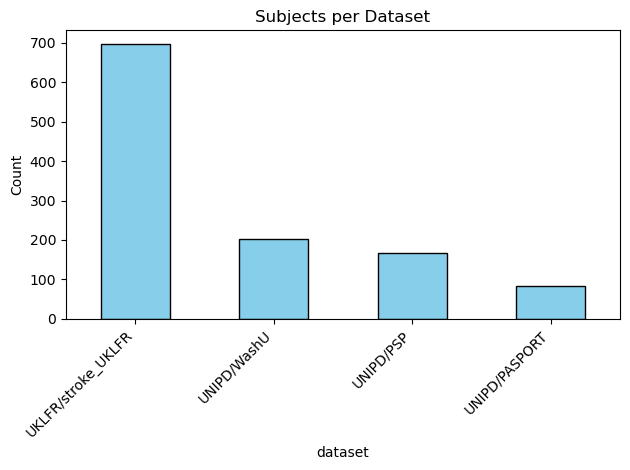

In [28]:
# Dataset distribution
if 'dataset' in df_meta.columns:
    df_meta['dataset'].value_counts().plot(kind='bar', title='Subjects per Dataset', color='skyblue', edgecolor='black')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Dataset column not found in metadata")

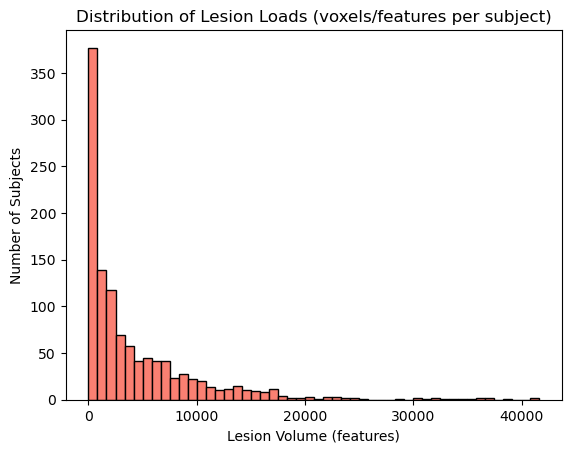

In [29]:
# Lesion load distribution (sum of lesion voxels per subject)
lesion_loads = matrix.sum(axis=1)
plt.hist(lesion_loads, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Lesion Loads (voxels/features per subject)')
plt.xlabel('Lesion Volume (features)')
plt.ylabel('Number of Subjects')
plt.show()

#### Statistiche descrittive del carico lesionale

Oltre all'istogramma sopra: tabella riassuntiva (`describe()`, percentili) e confronto tra i 4 dataset — i siti di acquisizione sono clinicamente diversi (coorti/criteri di reclutamento differenti), quindi vale la pena controllare se il carico lesionale è comparabile o sistematicamente diverso tra loro.

Statistiche descrittive del carico lesionale (n. voxel lesionati per soggetto):


count     1150.000000
mean      4424.272174
std       6042.513290
min          1.000000
25%        559.250000
50%       2010.000000
75%       6175.750000
max      41646.000000
Name: lesion_load_voxels, dtype: float64

p1        28.00
p5        95.45
p25      559.25
p50     2010.00
p75     6175.75
p95    16165.75
p99    31902.79
Name: lesion_load_voxels, dtype: float64

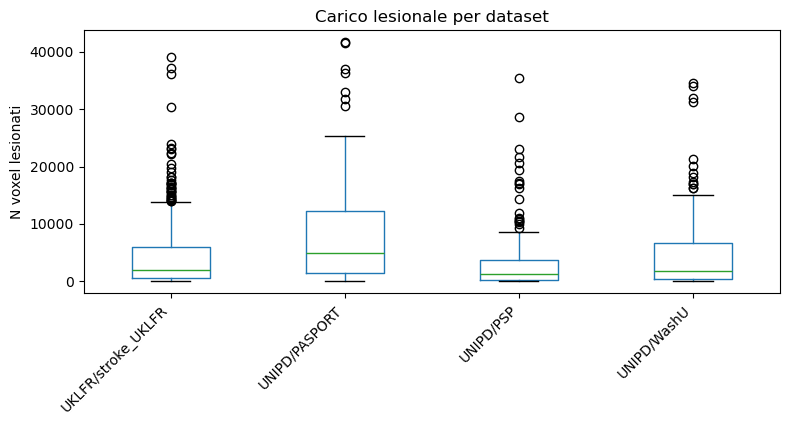

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
UKLFR/stroke_UKLFR,697.0,4149.995696,5149.695441,10.0,647.00,2041.0,5969.0,39071.0
UNIPD/PASPORT,83.0,8698.060241,10404.785317,139.0,1442.00,4968.0,12265.5,41646.0
UNIPD/PSP,168.0,3527.928571,5606.918821,17.0,290.75,1231.0,3664.5,35470.0
UNIPD/WashU,202.0,4360.074257,6174.558967,1.0,398.50,1815.5,6617.0,34477.0


In [30]:
print("Statistiche descrittive del carico lesionale (n. voxel lesionati per soggetto):")
display(pd.Series(lesion_loads, name="lesion_load_voxels").describe())

percentiles = [1, 5, 25, 50, 75, 95, 99]
pct_load = pd.Series(lesion_loads).quantile([p / 100 for p in percentiles])
pct_load.index = [f"p{p}" for p in percentiles]
display(pct_load.rename("lesion_load_voxels"))

if "dataset" in df_meta.columns:
    df_loads = df_meta.copy()
    df_loads["lesion_load_voxels"] = lesion_loads

    fig, ax = plt.subplots(figsize=(8, 4.5))
    df_loads.boxplot(column="lesion_load_voxels", by="dataset", ax=ax, grid=False)
    ax.set_title("Carico lesionale per dataset")
    ax.set_xlabel("")
    ax.set_ylabel("N voxel lesionati")
    plt.suptitle("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(df_loads.groupby("dataset")["lesion_load_voxels"].describe())
else:
    print("Dataset column not found in metadata")

#### Frequenza lesionale voxel-wise

Fin qui si è guardato *quanto* è lesionato ogni paziente (per riga). Guardiamo ora la prospettiva complementare: per ogni voxel/feature (per colonna), in quanti pazienti su 1150 è lesionato. Serve anche da controllo di coerenza sul filtro "voxel non-costanti" applicato a monte (nessun voxel di questa matrice dovrebbe risultare mai-lesionato o sempre-lesionato in tutta la coorte, altrimenti non sarebbe stato escluso come costante).

Frequenza voxel-wise calcolata su 254865 feature (voxel non-costanti già filtrati a monte)
Voxel mai lesionato in nessun soggetto (atteso 0, sono già esclusi come costanti): 0
Voxel lesionato in tutti i soggetti (atteso 0, stesso motivo): 0
Voxel lesionato in almeno il 10% della coorte: 3642
Voxel lesionato in almeno il 50% della coorte: 0
Voxel più frequentemente lesionato: 180/1150 soggetti (15.7%)


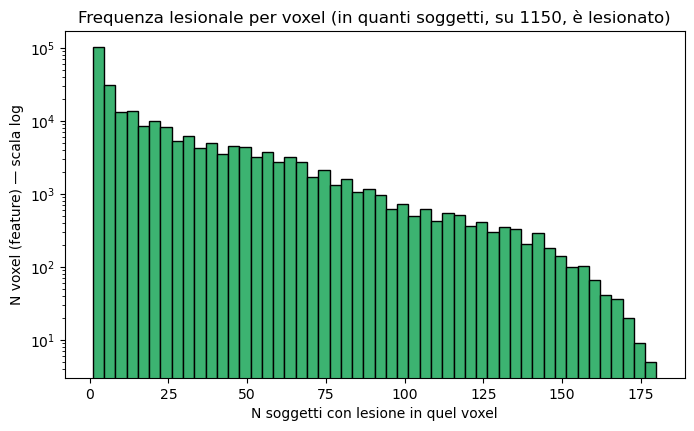

In [31]:
voxel_frequency = matrix.sum(axis=0)
n_subjects, n_voxels = matrix.shape

n_never_lesioned = int((voxel_frequency == 0).sum())
n_always_lesioned = int((voxel_frequency == n_subjects).sum())
print(f"Frequenza voxel-wise calcolata su {n_voxels} feature (voxel non-costanti già filtrati a monte)")
print(f"Voxel mai lesionato in nessun soggetto (atteso 0, sono già esclusi come costanti): {n_never_lesioned}")
print(f"Voxel lesionato in tutti i soggetti (atteso 0, stesso motivo): {n_always_lesioned}")
print(f"Voxel lesionato in almeno il 10% della coorte: {(voxel_frequency >= 0.10 * n_subjects).sum()}")
print(f"Voxel lesionato in almeno il 50% della coorte: {(voxel_frequency >= 0.50 * n_subjects).sum()}")
print(f"Voxel più frequentemente lesionato: {voxel_frequency.max()}/{n_subjects} soggetti ({voxel_frequency.max() / n_subjects:.1%})")

plt.figure(figsize=(8, 4.5))
plt.hist(voxel_frequency, bins=50, edgecolor="black", color="mediumseagreen")
plt.title("Frequenza lesionale per voxel (in quanti soggetti, su 1150, è lesionato)")
plt.xlabel("N soggetti con lesione in quel voxel")
plt.ylabel("N voxel (feature) — scala log")
plt.yscale("log")
plt.show()

## Masked FC matrices — controllo qualità a posteriori (Step 11)

**Natura di questa sezione**: nessuna cella qui ricalcola lesione, coverage o masking — tutto ciò che segue **legge soltanto artefatti già su disco**, prodotti da run passati reali di `mask_fc.py`/`build_fc_matrix.py` (`mask_summary.csv`, `matrix.npy`). È l'esplorazione a posteriori della domanda "per paziente" dello **Step 11 — controllo qualità dopo l'impilamento** (vedi [Parte 2](../assets/knowledge/fc_lesion_masking.md#controllo-qualità-dopo-limpilamento) e [Parte 3, step 9-12](../assets/knowledge/fc_lesion_masking.md#step-9-12--tutti-i-pazienti-insieme-build_fc_matrixpy) del `.md`) — non introduce un nuovo step della procedura.

**Contesto**: `mask_fc.py` + `build_fc_matrix.py` sono già girati su tutta la coorte WashU (169 pazienti, atlante `Yan200TianS2Buckner7N`). Per ogni paziente, se la sua lesione copre troppo un nodo cerebrale (soglia standard 50%, vedi `notebooks/fc_lesion_masking.ipynb`), quel nodo viene marcato come compromesso e le sue connessioni diventano `NaN` nella matrice finale.

**Quello che manca**: Step 11 si ferma a *misurare* quanto è compromesso ogni paziente — non decide un'esclusione. Oggi la matrice finale include tutti i 169 pazienti, senza escludere nessuno — anche chi ha moltissimi nodi compromessi. Questa sezione serve a guardare i dati reali prima di decidere se/dove aggiungere un passo di esclusione (che non esiste ancora nella procedura a 12 step).

### `mask_summary.csv` — quanti nodi sono compromessi, per paziente (proxy di Step 11)


Questo file dice, per ognuno dei 169 pazienti, quanti nodi (su 239 totali della mappa cerebrale) hanno una lesione troppo estesa per fidarsi della loro connettività — cioè quanti nodi sono stati marcati come "compromessi" secondo la soglia descritta in fc_lesion_masking.md (meno del 50% di tessuto sano).

Questo file esiste già su disco — è un byproduct del run reale di `mask_fc.py` (Step 3-4, [Parte 3](../assets/knowledge/fc_lesion_masking.md#step-1-8--per-ogni-paziente-mask_fcpy) del `.md`), qui viene solo **letto**, mai ricalcolato. `n_compromised_nodes` è una **proxy economica** per la domanda "per paziente" di **Step 11** (quanto è compromesso questo paziente?) — non è la metrica *esatta* di Step 11 (% di connessioni NaN sulla matrice finale impilata), calcolata e confrontata con questa proxy più sotto.

#### Loading

In [32]:
fc_base_dir = "/Users/emmatosato/Local Projects/PhD/NEMESIS_fs/data/derived/features"
atlas_combo = "Yan200TianS2Buckner7N"
n_total_nodes = 239  # nodi totali di questa mappa cerebrale (Yan200 corticali + Tian S2 subcorticali + Buckner7N cervelletto)

mask_summary_path = os.path.join(fc_base_dir, "masked_fc", atlas_combo, "mask_summary.csv")
df_mask_summary = pd.read_csv(mask_summary_path)

print(f"Pazienti nel run reale: {len(df_mask_summary)}")
display(df_mask_summary.head())
display(df_mask_summary["n_compromised_nodes"].describe())

Pazienti nel run reale: 169


,subject_id,n_compromised_nodes
0,sub-STUNIPD0002,0
1,sub-STUNIPD0003,8
2,sub-STUNIPD0005,2
3,sub-STUNIPD0006,9
4,sub-STUNIPD0008,0


count    169.000000
mean       3.881657
std        6.705379
min        0.000000
25%        0.000000
50%        1.000000
75%        5.000000
max       42.000000
Name: n_compromised_nodes, dtype: float64

#### Distribuzione: la maggior parte dei pazienti ha pochissimi nodi compromessi

*Ancora controllo qualità a posteriori di Step 11 — statistica descrittiva su `n_compromised_nodes` già caricato sopra, nessun nuovo calcolo sulla pipeline.*

Se la distribuzione fosse piatta (tanti pazienti sparsi su tutti i valori), una soglia sarebbe una scelta delicata. Guardiamo se invece c'è una massa di pazienti "puliti" e una coda di pochi pazienti molto compromessi — in quel caso la soglia taglierebbe solo la coda, con poco rischio di perdere dati buoni.

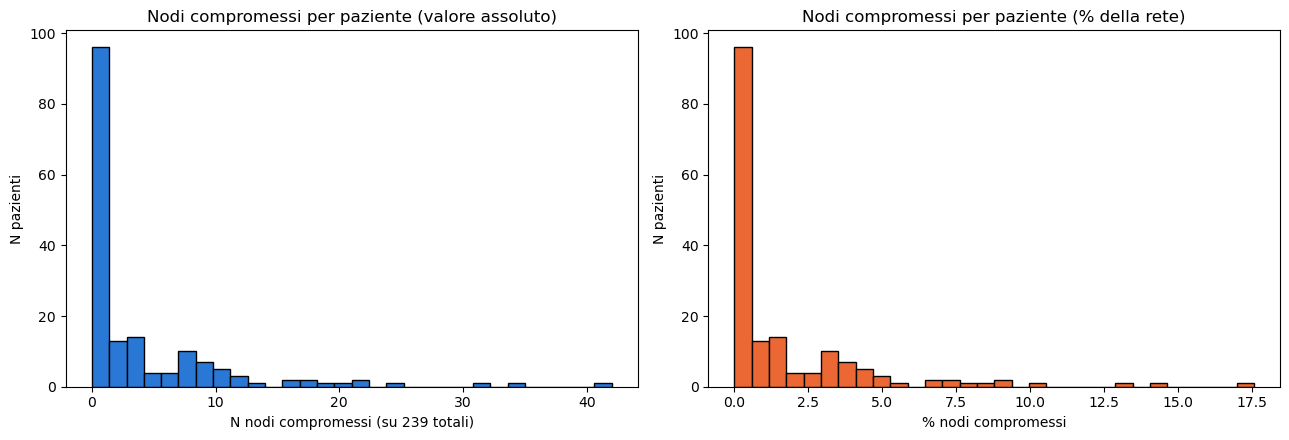

p50      1.00
p75      5.00
p90     11.00
p95     17.60
p99     31.96
p100    42.00
Name: n_compromised_nodes, dtype: float64

In [33]:
SERIES_BLUE = "#2a78d6"
SERIES_ORANGE = "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_mask_summary["n_compromised_nodes"], bins=30, edgecolor="black", color=SERIES_BLUE)
axes[0].set_title("Nodi compromessi per paziente (valore assoluto)")
axes[0].set_xlabel(f"N nodi compromessi (su {n_total_nodes} totali)")
axes[0].set_ylabel("N pazienti")

axes[1].hist(df_mask_summary["n_compromised_nodes"] / n_total_nodes * 100, bins=30, edgecolor="black", color=SERIES_ORANGE)
axes[1].set_title("Nodi compromessi per paziente (% della rete)")
axes[1].set_xlabel("% nodi compromessi")
axes[1].set_ylabel("N pazienti")

plt.tight_layout()
plt.show()

percentiles = [50, 75, 90, 95, 99, 100]
pct_table = df_mask_summary["n_compromised_nodes"].quantile([p / 100 for p in percentiles])
pct_table.index = [f"p{p}" for p in percentiles]
display(pct_table.rename("n_compromised_nodes"))

Un percentile risponde alla domanda "sotto quale valore sta il P% dei pazienti?". Es. p90 = 11 significa che il 90% dei 169 pazienti ha al massimo 11 nodi compromessi — solo il 10% (~17 pazienti) ne ha di più. Andando verso p95/p99/p100 ci si avvicina sempre più alla coda estrema della distribuzione (i pazienti più compromessi), fino al singolo valore massimo osservato (p100). Servono a capire quanto "in profondità nella coda" entreremmo scegliendo una soglia — non a decidere se tagliare una massa consistente di pazienti nella norma.

#### Quanti pazienti perderesti, a seconda di dove metti la soglia

*Step 11 misura, non decide*: la procedura a 12 step si ferma a quantificare quanto è compromesso ogni paziente, senza mai escluderne uno. Questa cella esplora — sempre a posteriori, sulla stessa proxy `n_compromised_nodes` — dove si potrebbe mettere una soglia per un passo di esclusione che oggi non esiste nella procedura (andrebbe inserito tra Step 9 e Step 10 di `build_fc_matrix.py`, prima dell'impilamento). Vediamo l'intera curva: per ogni soglia possibile (n nodi compromessi oltre cui un paziente verrebbe escluso), quanti pazienti restano fuori.

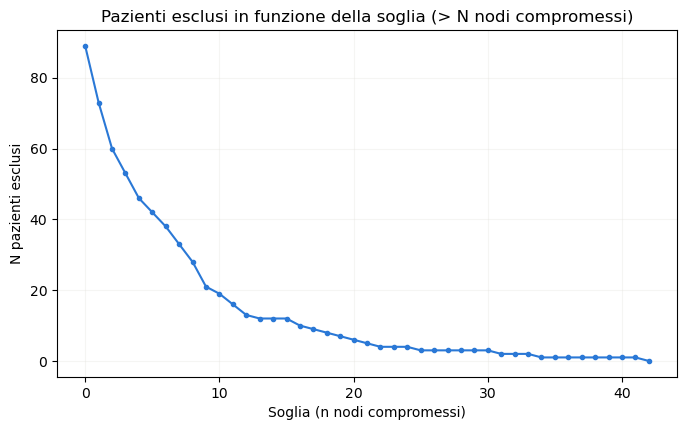

,soglia_nodi,soglia_%_rete,pazienti_esclusi,pazienti_rimasti
0,5,2.1,42,127
1,10,4.2,19,150
2,12,5.0,13,156
3,15,6.3,12,157
4,20,8.4,6,163
5,24,10.0,4,165
6,30,12.6,3,166
7,40,16.7,1,168


In [34]:
n_patients = len(df_mask_summary)
max_nodes = int(df_mask_summary["n_compromised_nodes"].max())
thresholds = np.arange(0, max_nodes + 1)
n_excluded = [(df_mask_summary["n_compromised_nodes"] > thr).sum() for thr in thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, n_excluded, marker="o", markersize=3, color=SERIES_BLUE)
plt.title("Pazienti esclusi in funzione della soglia (> N nodi compromessi)")
plt.xlabel("Soglia (n nodi compromessi)")
plt.ylabel("N pazienti esclusi")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

candidate_thresholds = [5, 10, 12, 15, 20, 24, 30, 40]
summary_df = pd.DataFrame({
    "soglia_nodi": candidate_thresholds,
    "soglia_%_rete": [round(t / n_total_nodes * 100, 1) for t in candidate_thresholds],
    "pazienti_esclusi": [(df_mask_summary["n_compromised_nodes"] > t).sum() for t in candidate_thresholds],
})
summary_df["pazienti_rimasti"] = n_patients - summary_df["pazienti_esclusi"]
display(summary_df)

Ogni riga rappresenta **una possibile soglia candidata** — non sono soglie già scelte, solo ipotesi da confrontare prima di deciderne una.

- **`soglia_nodi`**: la regola "escludi un paziente se ha più di questo numero di nodi compromessi" (su 239 nodi totali della mappa cerebrale).
- **`soglia_%_rete`**: la stessa identica soglia, espressa come percentuale del totale dei nodi (`soglia_nodi ÷ 239 × 100`) — utile per confrontare soglie su atlanti diversi, che hanno un numero di nodi totali diverso.
- **`pazienti_esclusi`**: quanti dei 169 pazienti verrebbero tolti dalla matrice finale, applicando quella soglia.
- **`pazienti_rimasti`**: quanti pazienti resterebbero (169 − `pazienti_esclusi`).

**Esempio concreto, riga per riga — soglia 12 nodi (5.0%)**: applicando la regola "escludi chi ha più di 12 nodi compromessi", 13 pazienti su 169 verrebbero esclusi (quelli con 13, 14, ..., fino a 42 nodi compromessi), e ne resterebbero 156.

**Il pattern generale lungo la tabella**: più si alza la soglia (righe verso il basso), meno pazienti vengono esclusi — perché una soglia più alta è più "permissiva" (tollera pazienti più compromessi). Il salto tra una riga e l'altra non è costante: tra soglia 10→12 si passa da 19 a 13 esclusi (salto di 6), mentre tra 12→15 si passa da 13 a 12 (salto di 1 solo) — segno che oltre soglia ~12 si è già usciti dalla parte "densa" della distribuzione ed entrati nella coda rara di pochi pazienti molto compromessi.


### Un nodo compromesso costa più di 1 connessione

Qui si calcola per la prima volta la metrica **esatta** di Step 11 (`fc_matrix.isna().sum(axis=1)` sulla matrice finale impilata, [Parte 2](../assets/knowledge/fc_lesion_masking.md#controllo-qualità-dopo-limpilamento) del `.md`) — non più la proxy `n_compromised_nodes` usata finora — per verificare quanto siano allineate.

Un dettaglio che rischia di sfuggire guardando solo il conteggio dei nodi: se un nodo è compromesso, tutte le sue connessioni con il resto della rete diventano NaN — fino a 238 connessioni perse per un solo nodo (su una rete di 239). Quindi "3 nodi compromessi" può voler dire poche decine di NaN o molte centinaia, a seconda di quali nodi sono coinvolti.

Esempio: 

Con un atlante giocattolo a 4 zone (A, B, C, D) ci sono 6 connessioni possibili in totale (A-B, A-C, A-D, B-C, B-D, C-D). Se solo la zona C è compromessa, diventano NaN tutte le connessioni che la coinvolgono — A-C, B-C, C-D — cioè 3 connessioni su 6 (50%), pur essendo compromessa 1 sola zona su 4. Nei dati reali (239 zone), un singolo nodo compromesso costa allo stesso modo fino a 238 connessioni su 28.441 totali — e se più zone sono compromesse insieme, il conteggio non è nemmeno una semplice somma (connessioni condivise, come C-D se sia C che D fossero compromesse, si contano una volta sola).

Guardiamo quindi la relazione reale tra nodi compromessi (proxy) e % di connessioni perse nella matrice finale (metrica esatta), per capire se contare i nodi è già una buona proxy o se serve guardare direttamente i NaN.

Matrice FC finale: 169 pazienti x 28441 connessioni
Frazione NaN sull'intera matrice: 0.0356


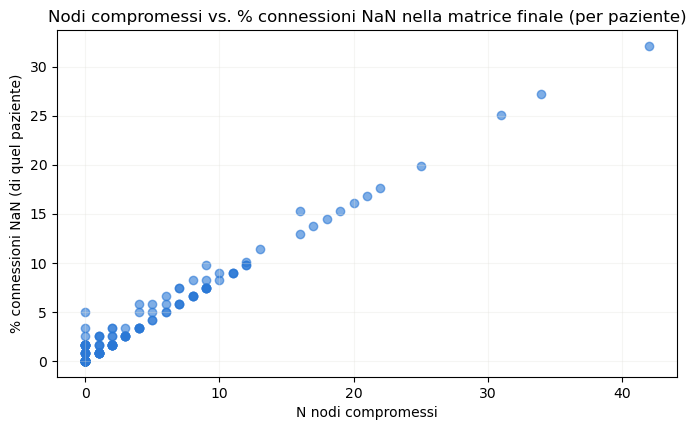

,subject_id,nan_edge_fraction_%,n_compromised_nodes
74,sub-STUNIPD0105,32.119124,42
73,sub-STUNIPD0104,27.196653,34
98,sub-STUNIPD0150,25.034281,31
133,sub-STUNIPD0202,19.865687,25
167,sub-STUNIPD0248,17.597834,22
168,sub-STUNIPD0250,16.834851,21
156,sub-STUNIPD0234,16.068352,20
134,sub-STUNIPD0203,15.298337,19
75,sub-STUNIPD0109,14.524806,18
163,sub-STUNIPD0242,13.747759,17


In [35]:
fc_matrix_dir = os.path.join(fc_base_dir, "fc_matrix", atlas_combo, "24-07_s1")

# Carica la matrice vera e propria: solo numeri, 169 righe (pazienti) x 28441 colonne (connessioni)
fc_matrix = np.load(os.path.join(fc_matrix_dir, "matrix.npy"))
df_fc_meta = pd.read_csv(os.path.join(fc_matrix_dir, "metadata.csv"))

# Stampa le dimensioni reali della matrice 
print(f"Matrice FC finale: {fc_matrix.shape[0]} pazienti x {fc_matrix.shape[1]} connessioni")
# np.isnan(...) trasforma ogni numero in Vero/Falso ("è NaN?"); .mean() su TUTTA la matrice
print(f"Frazione NaN sull'intera matrice: {np.isnan(fc_matrix).mean():.4f}")

# per ogni singolo paziente, che % delle sue 28441 connessioni è NaN
nan_fraction_per_subject = np.isnan(fc_matrix).mean(axis=1) * 100

df_nan = df_fc_meta.copy()
df_nan["nan_edge_fraction_%"] = nan_fraction_per_subject
# in ogni riga ha SIA i nodi compromessi SIA la % NaN reale, per lo stesso paziente
df_nan = df_nan.merge(df_mask_summary, on="subject_id", how="left")


plt.figure(figsize=(8, 4.5))
plt.scatter(df_nan["n_compromised_nodes"], df_nan["nan_edge_fraction_%"], alpha=0.6, color=SERIES_BLUE)
plt.title("Nodi compromessi vs. % connessioni NaN nella matrice finale (per paziente)")
plt.xlabel("N nodi compromessi")
plt.ylabel("% connessioni NaN (di quel paziente)")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

display(df_nan.sort_values("n_compromised_nodes", ascending=False).head(10))


Grafico a dispersione: un puntino per paziente. 
- Asse orizzontale = nodi compromessi (da prima),
- Asse verticale = % NaN reale (appena calcolata) 

Ordina i pazienti dal più compromesso al meno, mostra i primi 10 -> "classifica" dei candidati più forti all'esclusione, con accanto il dato NaN reale corrispondente